<a href="https://colab.research.google.com/github/kixcz/ml-projects-compilation/blob/main/Decision_Trees_Classification_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees: Classification and Regression
### Visual, hands-on Google Colab lesson

**Learning goals:** understand recursive splitting; compare Gini impurity and mean squared error; visualize the tree, decision regions, overfitting, pruning, and predictions. All data are generated in the notebook—no external files are needed.

**Important:** A decision tree classifier predicts discrete categories; a decision tree regressor predicts continuous values. Both partition feature space into regions, but optimize different split criteria.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.inspection import DecisionBoundaryDisplay

RANDOM_STATE = 42
plt.rcParams.update({'figure.figsize': (8, 5), 'axes.grid': True, 'grid.alpha': 0.2})
print('Ready: NumPy, Pandas, Matplotlib, and scikit-learn imported.')

Ready: NumPy, Pandas, Matplotlib, and scikit-learn imported.


# Part A — Decision Tree Classification
**Scenario:** classify a synthetic student as **Needs Support** (0) or **On Track** (1) from practice hours and attendance. These are invented instructional examples—not real student outcomes.

   Practice hours  Attendance (%)         Status
0        7.739560       66.332706       On Track
1        8.585979       81.842082       On Track
2        0.941773       98.537341  Needs Support
3        7.611397       87.163858       On Track
4        1.281136       67.023156  Needs Support


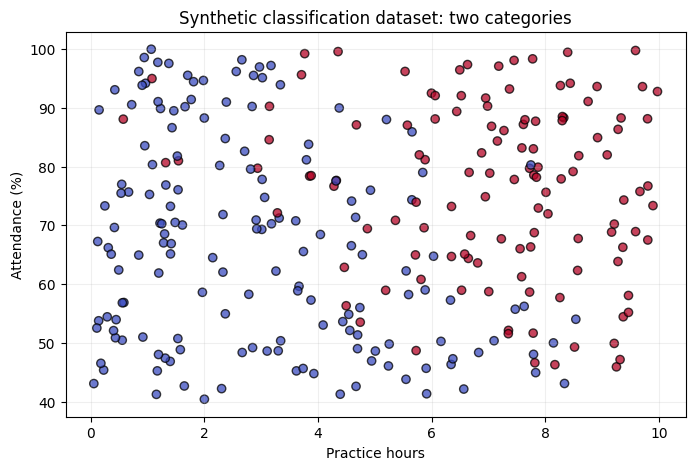

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
X_c = rng.uniform([0, 40], [10, 100], size=(280, 2))
score = X_c[:, 0] * 0.75 + (X_c[:, 1] - 40) * 0.075 + rng.normal(0, 1.25, 280)
y_c = (score >= 6.2).astype(int)
features_c = ['Practice hours', 'Attendance (%)']
print(pd.DataFrame(X_c, columns=features_c).assign(Status=np.where(y_c == 1, 'On Track', 'Needs Support')).head())
plt.figure(figsize=(8, 5))
plt.scatter(X_c[:, 0], X_c[:, 1], c=y_c, cmap='coolwarm', edgecolor='k', alpha=.75)
plt.xlabel(features_c[0]); plt.ylabel(features_c[1]); plt.title('Synthetic classification dataset: two categories')
plt.show()

## 1. Train the classifier
A split such as `Practice hours <= 4.8` routes observations left or right. With **Gini impurity**, a pure node has a score of 0; mixed nodes have higher values.

\(Gini = 1 - \sum_{k=1}^{C} p_k^2\), where \(p_k\) is the proportion of class \(k\) in the node.

In [3]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_c, y_c, test_size=0.25, stratify=y_c, random_state=RANDOM_STATE)
clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, random_state=RANDOM_STATE, criterion='gini')
clf.fit(Xc_train, yc_train)
print(export_text(clf, feature_names=features_c, decimals=2))
print('First split feature:', features_c[clf.tree_.feature[0]])
print('First split threshold:', round(float(clf.tree_.threshold[0]), 2))

|--- Practice hours <= 6.34
|   |--- Practice hours <= 3.12
|   |   |--- Attendance (%) <= 79.64
|   |   |   |--- class: 0
|   |   |--- Attendance (%) >  79.64
|   |   |   |--- class: 0
|   |--- Practice hours >  3.12
|   |   |--- Attendance (%) <= 90.10
|   |   |   |--- class: 0
|   |   |--- Attendance (%) >  90.10
|   |   |   |--- class: 1
|--- Practice hours >  6.34
|   |--- Attendance (%) <= 48.85
|   |   |--- class: 0
|   |--- Attendance (%) >  48.85
|   |   |--- Attendance (%) <= 58.37
|   |   |   |--- class: 1
|   |   |--- Attendance (%) >  58.37
|   |   |   |--- class: 1

First split feature: Practice hours
First split threshold: 6.34


## 2. Visualize the actual classification tree
Each box shows the split rule, Gini impurity, sample count, and counts per class. A leaf node makes the final prediction.

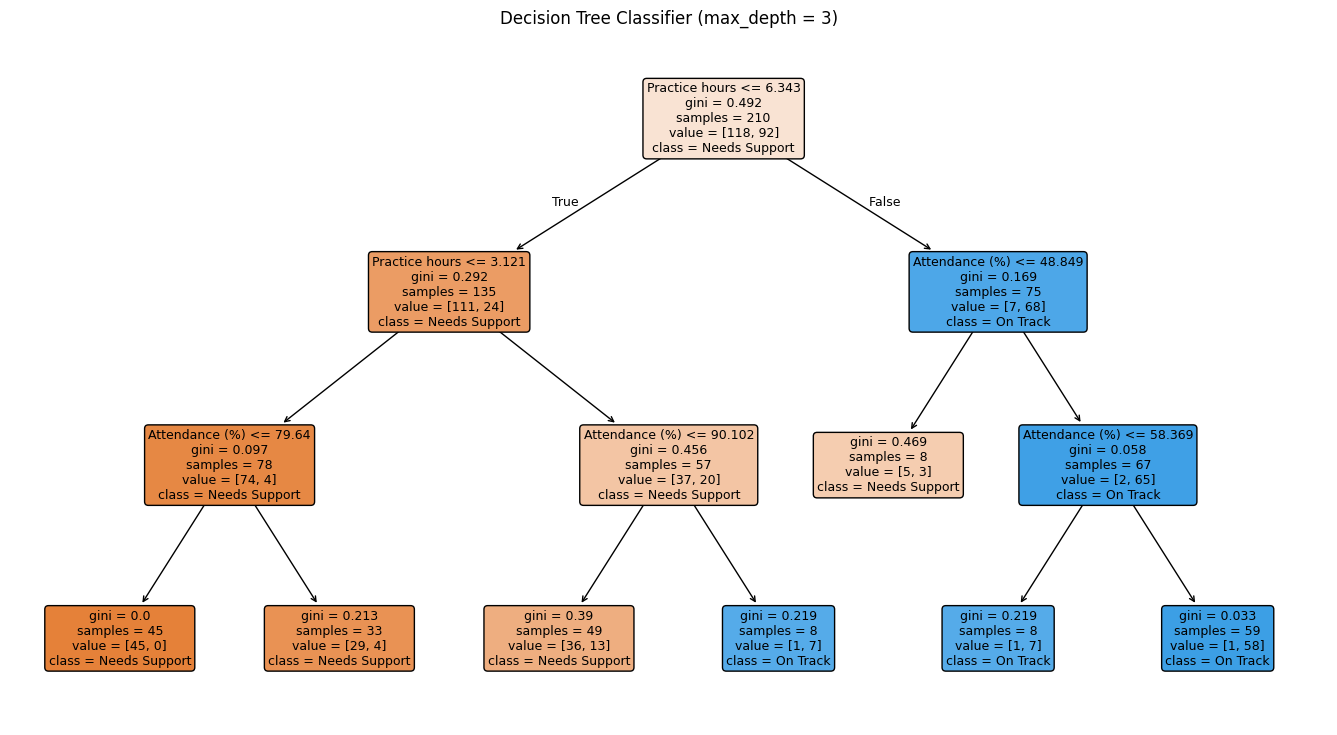

In [4]:
plt.figure(figsize=(17, 9))
plot_tree(clf, feature_names=features_c, class_names=['Needs Support', 'On Track'],
          filled=True, rounded=True, fontsize=9, proportion=False)
plt.title('Decision Tree Classifier (max_depth = 3)'); plt.show()

## 3. Decision boundary
Unlike a linear classifier, an ordinary decision tree divides the space with **axis-aligned** (horizontal or vertical) cuts.

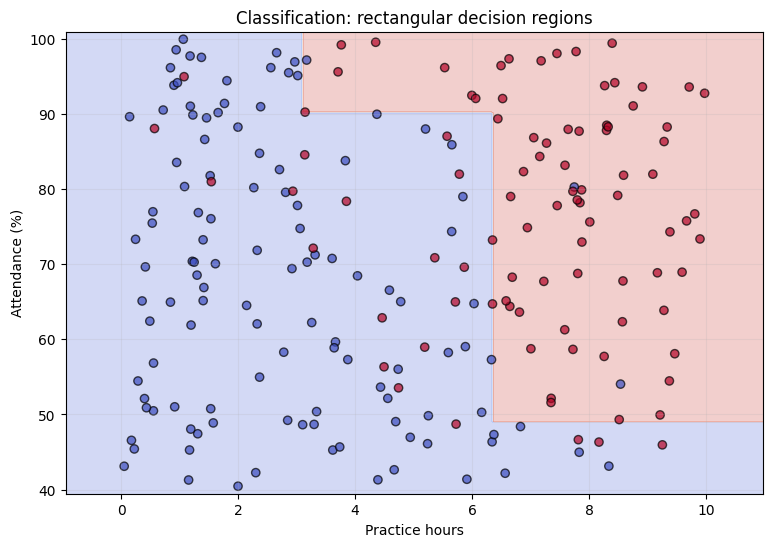

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
DecisionBoundaryDisplay.from_estimator(clf, X_c, response_method='predict', cmap='coolwarm', alpha=.25, ax=ax, grid_resolution=250)
ax.scatter(Xc_train[:, 0], Xc_train[:, 1], c=yc_train, cmap='coolwarm', edgecolors='black', alpha=.7, label='Training observations')
ax.set(xlabel=features_c[0], ylabel=features_c[1], title='Classification: rectangular decision regions')
plt.show()

## 4. Overfitting and tree depth
A deeper tree can memorize the training set. Compare training and test accuracy for different maximum depths.

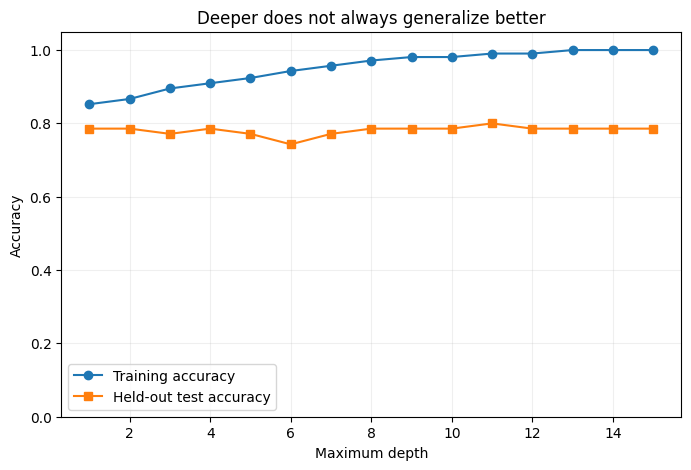

Use cross-validation on the training set, not the test set, to select hyperparameters.


In [6]:
depths = range(1, 16)
train_acc, test_acc = [], []
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(Xc_train, yc_train)
    train_acc.append(accuracy_score(yc_train, model.predict(Xc_train)))
    test_acc.append(accuracy_score(yc_test, model.predict(Xc_test)))
plt.plot(list(depths), train_acc, 'o-', label='Training accuracy')
plt.plot(list(depths), test_acc, 's-', label='Held-out test accuracy')
plt.xlabel('Maximum depth'); plt.ylabel('Accuracy'); plt.ylim(0, 1.05); plt.legend(); plt.title('Deeper does not always generalize better'); plt.show()
print('Use cross-validation on the training set, not the test set, to select hyperparameters.')

## 5. Evaluate classification
A confusion matrix separates correct from incorrect predictions. Accuracy alone does not tell you which class is harder to identify.

Test accuracy: 0.771
               precision    recall  f1-score   support

Needs Support       0.76      0.88      0.81        40
     On Track       0.79      0.63      0.70        30

     accuracy                           0.77        70
    macro avg       0.78      0.75      0.76        70
 weighted avg       0.77      0.77      0.77        70



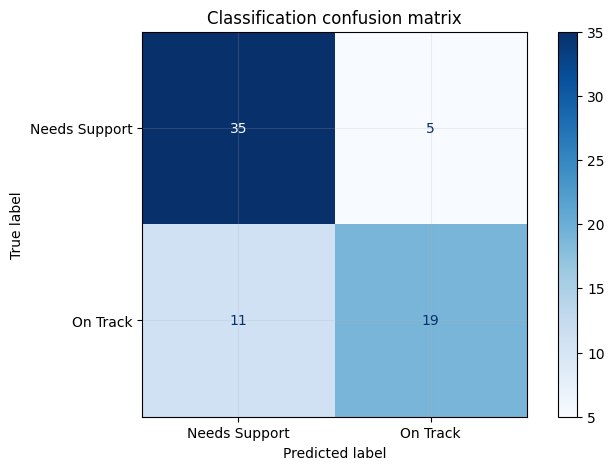

In [7]:
pred_c = clf.predict(Xc_test)
print('Test accuracy:', round(accuracy_score(yc_test, pred_c), 3))
print(classification_report(yc_test, pred_c, target_names=['Needs Support', 'On Track']))
ConfusionMatrixDisplay.from_predictions(yc_test, pred_c, display_labels=['Needs Support', 'On Track'], cmap='Blues')
plt.title('Classification confusion matrix'); plt.show()

## 6. Predict a new student
Change the input values to try another hypothetical student.

In [8]:
new_student = pd.DataFrame([[6.0, 88.0]], columns=features_c)
predicted_class = clf.predict(new_student)[0]
prob = clf.predict_proba(new_student)[0]
print('Input:', new_student.to_dict(orient='records')[0])
print('Predicted category:', ['Needs Support', 'On Track'][predicted_class])
print('Estimated class proportions in predicted leaf:', dict(zip(['Needs Support', 'On Track'], np.round(prob, 3))))
print('Note: leaf class proportions are not necessarily well-calibrated probabilities.')

Input: {'Practice hours': 6.0, 'Attendance (%)': 88.0}
Predicted category: Needs Support
Estimated class proportions in predicted leaf: {'Needs Support': np.float64(0.735), 'On Track': np.float64(0.265)}
Note: leaf class proportions are not necessarily well-calibrated probabilities.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


# Part B — Decision Tree Regression
**Scenario:** estimate a synthetic numeric performance score using study hours. A regression tree predicts the **mean target value within each leaf**, producing a piecewise-constant (stair-step) curve.

The usual `squared_error` criterion chooses splits that reduce the sum of squared deviations within child nodes.

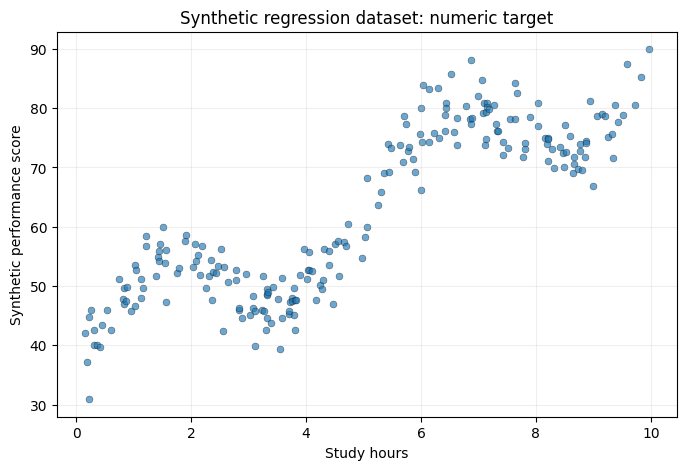

In [9]:
rng = np.random.default_rng(24)
X_r = np.sort(rng.uniform(0, 10, 220)).reshape(-1, 1)
y_r = 38 + 5 * X_r.ravel() + 9 * np.sin(1.25 * X_r.ravel()) + rng.normal(0, 3.5, len(X_r))
fig, ax = plt.subplots()
ax.scatter(X_r[:, 0], y_r, s=25, alpha=.65, edgecolor='k', linewidth=.3)
ax.set(xlabel='Study hours', ylabel='Synthetic performance score', title='Synthetic regression dataset: numeric target')
plt.show()

## 7. Train and visualize the regression tree

|--- Study hours <= 5.02
|   |--- Study hours <= 0.67
|   |   |--- value: [41.08]
|   |--- Study hours >  0.67
|   |   |--- Study hours <= 2.54
|   |   |   |--- value: [52.85]
|   |   |--- Study hours >  2.54
|   |   |   |--- value: [48.54]
|--- Study hours >  5.02
|   |--- Study hours <= 6.01
|   |   |--- value: [70.76]
|   |--- Study hours >  6.01
|   |   |--- Study hours <= 7.28
|   |   |   |--- value: [79.59]
|   |   |--- Study hours >  7.28
|   |   |   |--- value: [75.43]



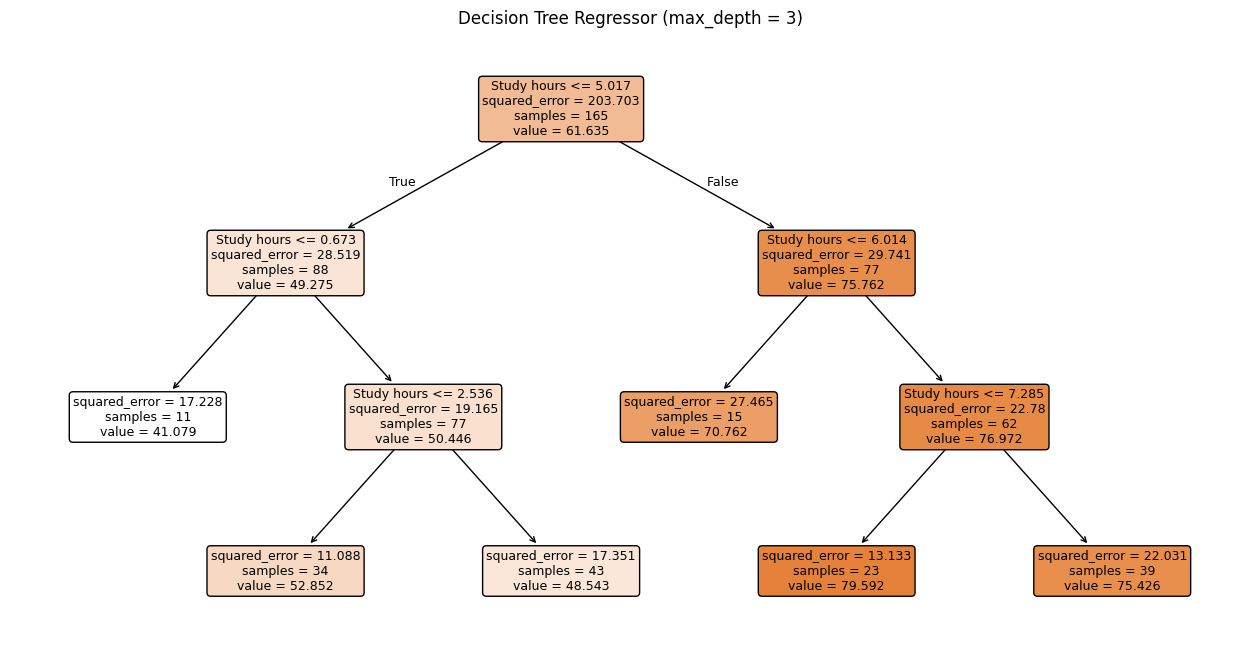

In [10]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_r, y_r, test_size=.25, random_state=RANDOM_STATE)
reg = DecisionTreeRegressor(max_depth=3, min_samples_leaf=8, random_state=RANDOM_STATE)
reg.fit(Xr_train, yr_train)
print(export_text(reg, feature_names=['Study hours'], decimals=2))
plt.figure(figsize=(16, 8))
plot_tree(reg, feature_names=['Study hours'], filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Regressor (max_depth = 3)'); plt.show()

## 8. Regression prediction curve
The staircase is **not** a fitted straight line. Every leaf predicts one constant value, usually the mean training response in that leaf.

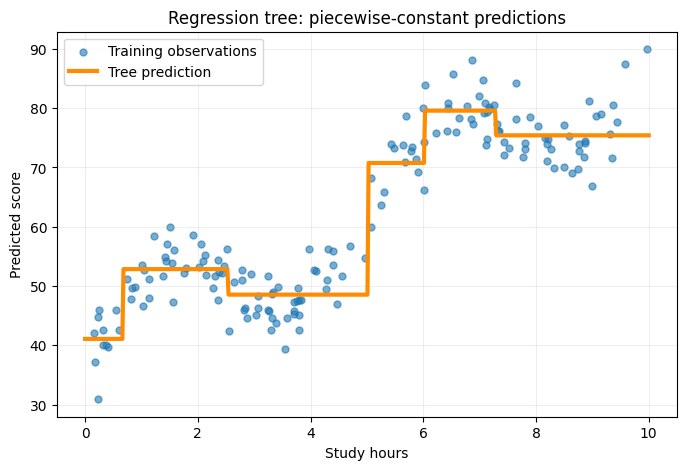

In [11]:
grid = np.linspace(0, 10, 500).reshape(-1, 1)
plt.scatter(Xr_train[:, 0], yr_train, s=25, alpha=.6, label='Training observations')
plt.plot(grid[:, 0], reg.predict(grid), linewidth=3, color='darkorange', label='Tree prediction')
plt.xlabel('Study hours'); plt.ylabel('Predicted score'); plt.title('Regression tree: piecewise-constant predictions'); plt.legend(); plt.show()

## 9. Effect of max_depth on regression
Small trees may underfit; very deep trees may chase noise.

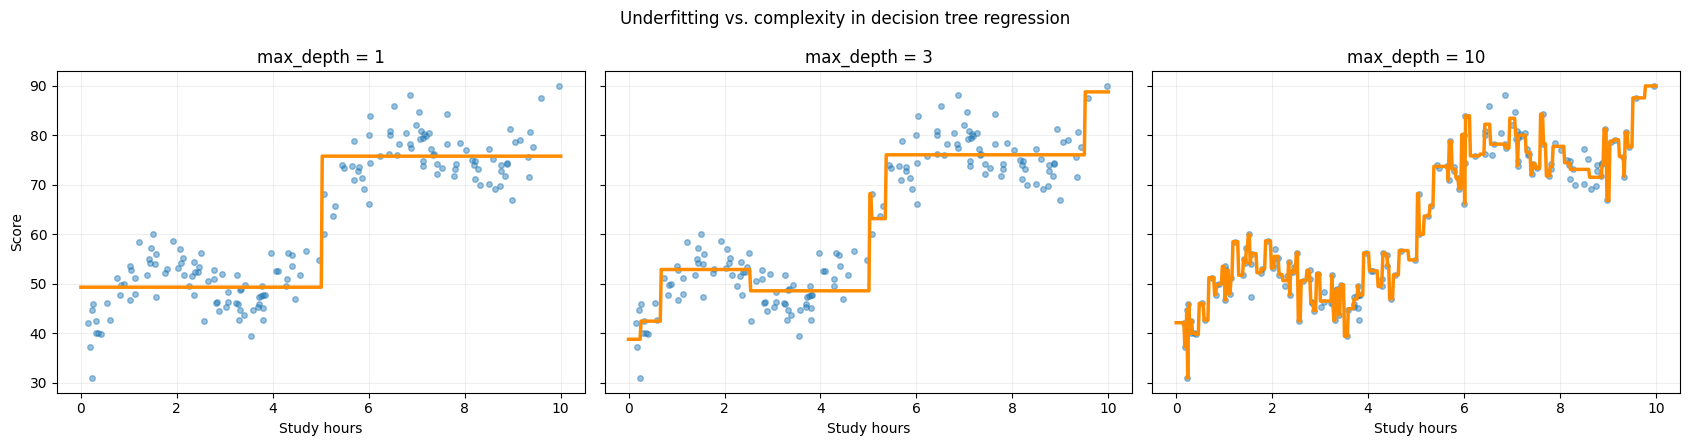

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), sharex=True, sharey=True)
for ax, depth in zip(axes, [1, 3, 10]):
    m = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(Xr_train, yr_train)
    ax.scatter(Xr_train[:, 0], yr_train, s=16, alpha=.45)
    ax.plot(grid[:, 0], m.predict(grid), color='darkorange', linewidth=2.5)
    ax.set_title(f'max_depth = {depth}')
    ax.set_xlabel('Study hours')
axes[0].set_ylabel('Score')
fig.suptitle('Underfitting vs. complexity in decision tree regression'); fig.tight_layout(); plt.show()

## 10. Evaluate regression
- **MAE:** average absolute prediction error (same units as the score).
- **RMSE:** penalizes larger errors more heavily.
- **R²:** fraction of test-target variation captured relative to predicting the test-target mean; can be negative.

Test MAE: 4.22 | RMSE: 5.12 | R²: 0.853


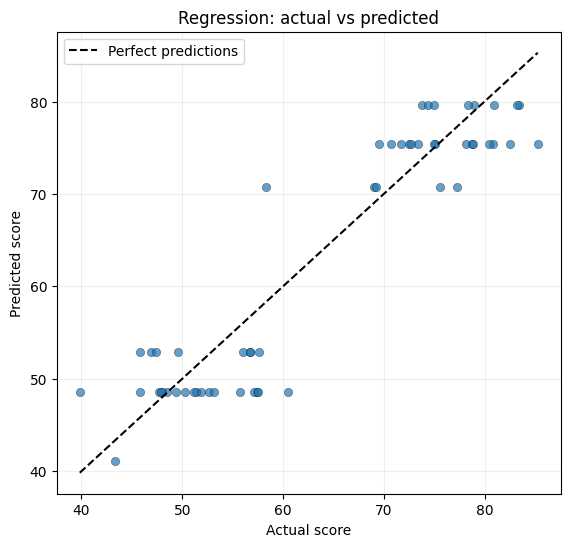

In [13]:
pred_r = reg.predict(Xr_test)
mae = mean_absolute_error(yr_test, pred_r)
rmse = np.sqrt(mean_squared_error(yr_test, pred_r))
r2 = r2_score(yr_test, pred_r)
print(f'Test MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}')
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(yr_test, pred_r, alpha=.7, edgecolor='k', linewidth=.3)
lims = [min(yr_test.min(), pred_r.min()), max(yr_test.max(), pred_r.max())]
ax.plot(lims, lims, 'k--', label='Perfect predictions')
ax.set(xlabel='Actual score', ylabel='Predicted score', title='Regression: actual vs predicted')
ax.legend(); plt.show()

## 11. Predict a numeric score for a new observation

In [14]:
study_hours = pd.DataFrame([[7.0]], columns=['Study hours'])
print(f'Predicted score for {study_hours.iloc[0,0]:.1f} study hours: {reg.predict(study_hours)[0]:.2f}')

Predicted score for 7.0 study hours: 79.59


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


# Part C — Side-by-side comparison

| Aspect | Classification tree | Regression tree |
|---|---|---|
| Target | Discrete class | Continuous number |
| Split objective | Reduce Gini impurity or entropy | Reduce squared error (or other numeric loss) |
| Leaf output | Majority class / class proportions | Mean value (for squared-error criterion) |
| Typical plot | Decision boundary + confusion matrix | Staircase fit + actual vs predicted |
| Useful metrics | Accuracy, precision, recall, F1 | MAE, RMSE, R² |

## Try it yourself
1. Change classifier depth from 3 to 1 and 8. How do decision regions change?
2. Replace `criterion='gini'` with `criterion='entropy'`. Does the root split change?
3. Increase `min_samples_leaf`. Does that simplify the model?
4. Change regression tree depth to 1 or 10. What happens to the staircase?
5. Explain why classification uses categories whereas regression predicts a number.

**Teaching caution:** These synthetic examples illustrate model mechanics, not causal effects of attendance or study time on performance. For real model selection, tune hyperparameters using cross-validation on training data, then evaluate once on a held-out test set.